In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import yfinance as yf
import pandas as pd
from io import StringIO
import requests
from requests.adapters import HTTPAdapter
import urllib3
import ssl, certifi
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import coint
import sys

sys.path.append('..')

from utils.stats_tests import pair_adf_test



urllib3.disable_warnings()

session = requests.Session()
session.verify = False

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

## Get tickers for top 100 s&p stocks

In [3]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"

headers = {
    "User-Agent": "Mozilla/5.0"
}

html = requests.get(url, headers=headers).text
table = pd.read_html(StringIO(html))[0]

tickers = table["Symbol"].str.replace(".", "-", regex=False).tolist()

len(tickers), tickers[:10]

(503, ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A'])

In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_info(ticker):
    try:
        return ticker, yf.Ticker(ticker).info
    except Exception as e:
        return ticker, {}

results = {}
with ThreadPoolExecutor(max_workers=20) as executor:
    futures = {executor.submit(fetch_info, t): t for t in tickers}
    for future in as_completed(futures):
        ticker, info = future.result()
        results[ticker] = info

ticker_info = pd.DataFrame(results).T

In [5]:
top_100_tickers = ticker_info['marketCap'].dropna().sort_values(ascending=False)[:100].index.tolist()
top_100_tickers[:10]

['NVDA',
 'GOOGL',
 'GOOG',
 'AAPL',
 'MSFT',
 'AMZN',
 'AVGO',
 'META',
 'TSLA',
 'BRK-B']

In [6]:
tickers = top_100_tickers

df = yf.download(
    tickers,
    start='2018-01-01',
    end='2025-01-01',
    auto_adjust=False,
    progress=False
)
df.head()

$SCHW: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01)
$LIN: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01)
$MU: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01)
$TXN: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01)
$SNDK: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1735707600")
$SYK: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01)

6 Failed downloads:
['SCHW', 'LIN', 'MU', 'TXN', 'SYK']: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01)
['SNDK']: possibly delisted; no price data found  (1d 2018-01-01 -> 2025-01-01) (Yahoo error = "Data doesn't exist for startDate = 1514782800, endDate = 1735707600")


Price       Adj Close                                                          \
Ticker           AAPL       ABBV        ABT         ACN        ADI       AMAT   
Date                                                                            
2018-01-02  40.304173  69.343697  50.822933  135.558228  77.602280  48.374264   
2018-01-03  40.297150  70.428856  50.935318  136.183868  78.565010  49.231564   
2018-01-04  40.484329  70.027222  50.848881  137.796402  78.479073  49.514301   
2018-01-05  40.945259  71.246223  50.995831  138.933105  78.797096  49.797035   
2018-01-08  40.793171  70.104713  50.848881  140.043365  78.934601  51.000904   

Price                                                ...   Volume           \
Ticker        AMD        AMGN       AMZN       ANET  ...      UNH      UNP   
Date                                                 ...                     
2018-01-02  10.98  137.775162  59.450500  14.439375  ...  3485000  4298000   
2018-01-03  11.55  140.375015  60.209999  14.725000  ...  2417600  4653700   
2018-01-04  12.12  139.783417  60.479500  14.543125  ...  2749100  4384900   
2018-01-05  11.88  140.616241  61.457001  14.798125  ...  2432800  5381200   
2018-01-08  12.28  140.577393  62.343498  15.691250  ...  2850800  5472300   

Price                                                                    \
Ticker            V VRT        VZ      WDC     WELL       WFC       WMT   
Date                                                                      
2018-01-02  6080900 NaN  16045300  5151762  1997300  13819300  30451500   
2018-01-03  6946100 NaN  16662400  4304116  1832600  14203700  26710800   
2018-01-04  7805300 NaN  12062800  6844011  1993500  18740500  20491200   
2018-01-05  8590500 NaN  13348900  3608350  2003300  14217900  21852000   
2018-01-08  6660700 NaN  16212700  6450022  1623200  15569400  26531700   

Price                 
Ticker           XOM  
Date                  
2018-01-02  11469300  
2018-01-03  13957700  
2018-01-04  10863000  
2018-01-05  11047600  
2018-01-08  10927100  

[5 rows x 600 columns]

In [7]:
adj_close = df['Adj Close']

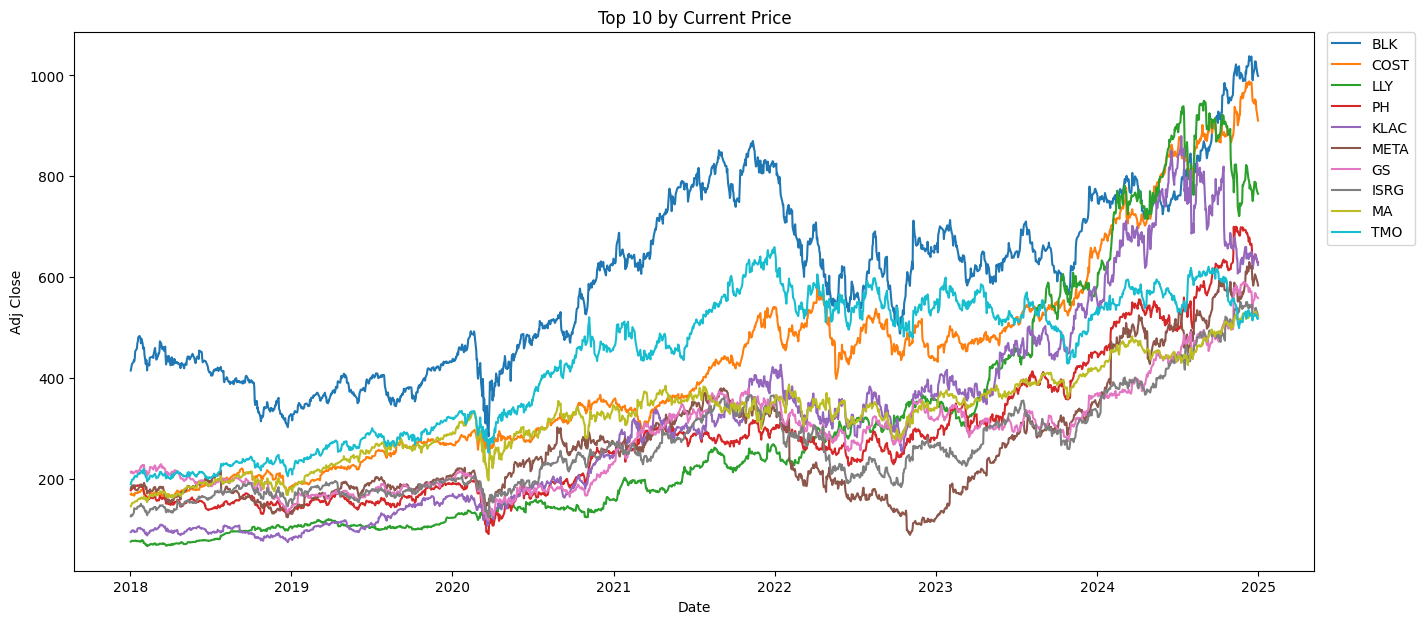

In [8]:
top10 = adj_close.iloc[-1].sort_values(ascending=False).head(10).index
melted = adj_close[top10].reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Adj Close')

plt.figure(figsize=(16, 7))
sns.lineplot(data=melted, x='Date', y='Adj Close', hue='Ticker')
plt.title('Top 10 by Current Price')
plt.legend(bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.show()

log returns correlation

In [9]:
adj_close

Ticker,AAPL,ABBV,ABT,ACN,ADI,AMAT,AMD,AMGN,AMZN,ANET,...,UNH,UNP,V,VRT,VZ,WDC,WELL,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-02,40.304173,69.343697,50.822933,135.558228,77.602280,48.374264,10.980000,137.775162,59.450500,14.439375,...,193.090469,113.271843,108.111900,NaN,33.712955,56.182053,48.156017,48.653324,28.855196,58.580437
2018-01-03,40.297150,70.428856,50.935318,136.183868,78.565010,49.231564,11.550000,140.375015,60.209999,14.725000,...,195.116028,113.905853,109.188210,NaN,33.020184,57.072628,48.238743,49.027645,29.106903,59.730953
2018-01-04,40.484329,70.027222,50.848881,137.796402,78.479073,49.514301,12.120000,139.783417,60.479500,14.543125,...,195.962875,113.288528,109.594193,NaN,33.127235,56.727455,47.200863,49.640888,29.133238,59.813610
2018-01-05,40.945259,71.246223,50.995831,138.933105,78.797096,49.797035,11.880000,140.616241,61.457001,14.798125,...,199.699707,114.731743,112.218857,NaN,33.051659,57.086441,46.907562,49.975384,29.305923,59.765404
2018-01-08,40.793171,70.104713,50.848881,140.043365,78.934601,51.000904,12.280000,140.577393,62.343498,15.691250,...,196.233597,116.325127,112.672050,NaN,32.994976,56.223480,47.073013,49.409927,29.739086,60.034073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,256.797211,172.530670,112.058289,353.541504,213.882050,166.493668,126.290001,254.389465,229.050003,114.650002,...,490.125610,223.228928,317.733398,118.542809,36.058937,46.435989,123.967651,69.724731,91.613251,101.953667
2024-12-26,257.612732,171.763855,112.556274,352.368317,213.852631,165.682785,125.059998,253.129501,227.050003,114.860001,...,495.016205,223.695282,317.991028,118.682579,36.203903,46.443520,123.771797,69.890312,91.722000,102.039902
2024-12-27,254.201370,170.623245,112.282867,348.213379,212.803284,164.970810,125.190002,252.619705,223.750000,113.029999,...,493.892822,223.403809,315.761536,114.918839,36.167652,45.683380,122.410599,69.257248,90.605011,102.030319


In [10]:
log_returns = np.log(adj_close / adj_close.shift(1)).iloc[1:].dropna(axis=1)
log_returns.head()


Ticker,AAPL,ABBV,ABT,ACN,ADI,AMAT,AMD,AMGN,AMZN,ANET,...,TSLA,UNH,UNP,V,VZ,WDC,WELL,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-03,-0.000174,0.015528,0.002209,0.004605,0.012330,0.017567,0.050610,0.018694,0.012694,0.019588,...,-0.010286,0.010436,0.005582,0.009906,-0.020763,0.015727,0.001716,0.007664,0.008685,0.019450
2018-01-04,0.004634,-0.005719,-0.001698,0.011771,-0.001094,0.005727,0.048172,-0.004223,0.004466,-0.012428,...,-0.008325,0.004331,-0.005434,0.003711,0.003237,-0.006066,-0.021750,0.012431,0.000904,0.001383
2018-01-05,0.011321,0.017258,0.002886,0.008215,0.004044,0.005694,-0.020001,0.005940,0.016033,0.017382,...,0.006210,0.018890,0.012659,0.023667,-0.002284,0.006308,-0.006233,0.006716,0.005910,-0.000806
2018-01-08,-0.003721,-0.016152,-0.002886,0.007960,0.001744,0.023888,0.033116,-0.000276,0.014322,0.058603,...,0.060755,-0.017509,0.013792,0.004030,-0.001716,-0.015232,0.003521,-0.011379,0.014673,0.004485
2018-01-09,-0.000114,0.007510,0.001698,0.003330,-0.002071,-0.019138,-0.038179,0.015276,0.004665,-0.004311,...,-0.008118,0.004971,0.011125,-0.001929,-0.003674,-0.010120,-0.019685,0.003540,-0.012079,-0.004255


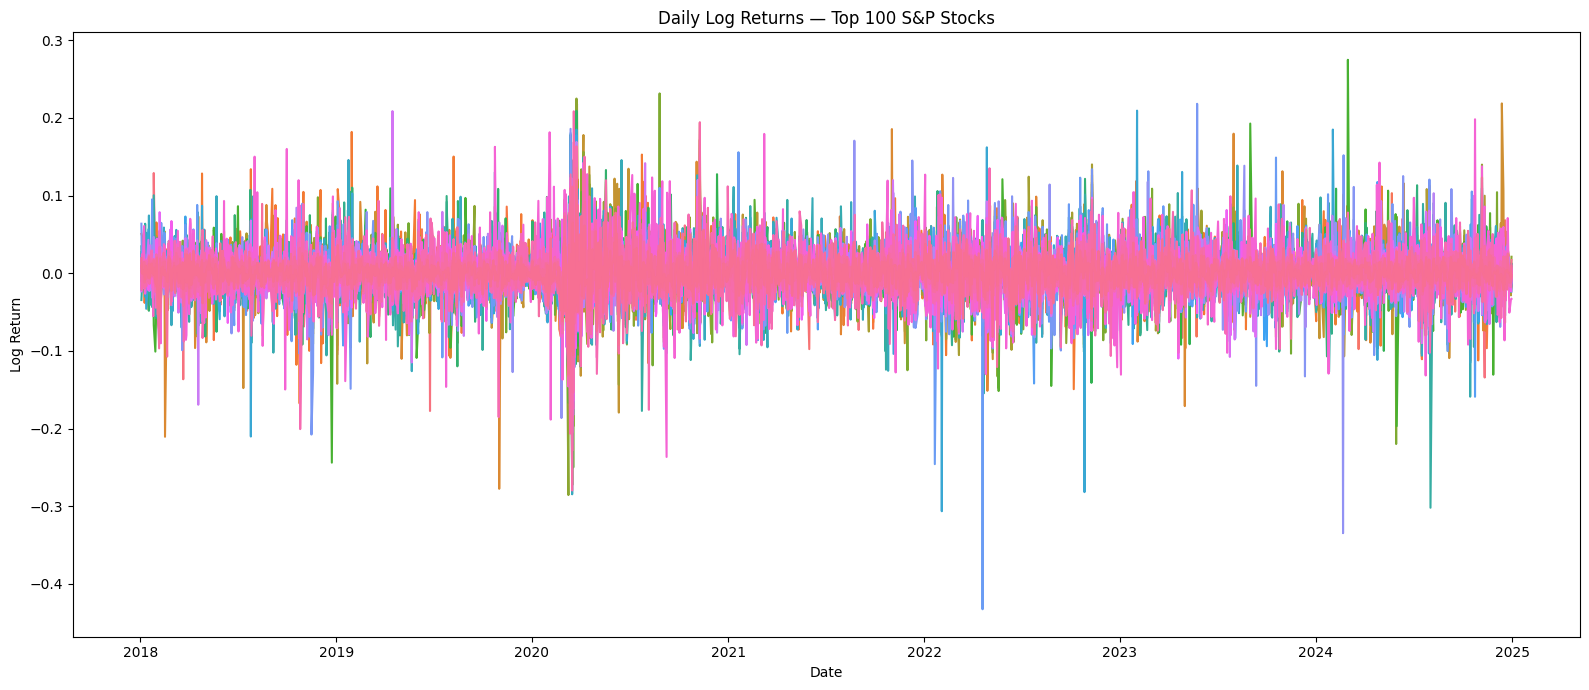

In [11]:
melted = log_returns.reset_index().melt(id_vars='Date', var_name='Ticker', value_name='Log Return')

plt.figure(figsize=(16, 7))
sns.lineplot(data=melted, x='Date', y='Log Return', hue='Ticker', legend=False)
plt.title('Daily Log Returns — Top 100 S&P Stocks')
plt.tight_layout()
plt.show()

In [12]:
corr = log_returns.corr()

In [24]:
corr_sum = (corr > 0.9).sum()
corr_sum[corr_sum > 1]

Ticker
AMAT     2
GOOG     2
GOOGL    2
LRCX     2
MA       2
V        2
dtype: int64

In [29]:
test = 'MA'
corr[test][corr[test] > 0.8]

Ticker
MA    1.000000
V     0.904798
Name: MA, dtype: float64

In [30]:
s1, s2 = 'MA', 'V'

we find s1 and s2 have high corr, lets look at cointegration

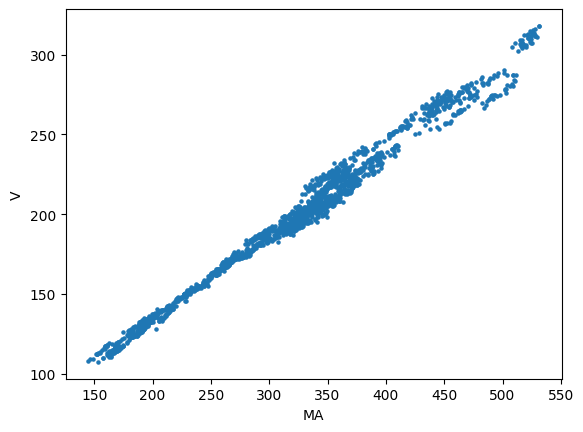

In [31]:
adj_close[[s1, s2]].plot(kind='scatter', x=s1, y=s2, marker='.')
plt.show()

In [32]:
pair_adf_test(adj_close[s1], adj_close[s2], s1, s2)
pair_adf_test(adj_close[s2], adj_close[s1], s2, s1)

  ADF STATIONARITY TESTS
  MA
    ADF Statistic :    -0.7104
    p-value       :     0.8440  ✗ non-stationary
    Critical Values: 1%=-3.434  5%=-2.863  10%=-2.568

  V
    ADF Statistic :    -0.4975
    p-value       :     0.8925  ✗ non-stationary
    Critical Values: 1%=-3.434  5%=-2.863  10%=-2.568

  COINTEGRATION TEST  (MA ~ V)
  ADF Statistic  :    -5.5914
  p-value        :     0.0000  (✓ cointegrated at 5% level)
  Critical Values: 1%=-3.903  5%=-3.340  10%=-3.047
  ADF STATIONARITY TESTS
  V
    ADF Statistic :    -0.4975
    p-value       :     0.8925  ✗ non-stationary
    Critical Values: 1%=-3.434  5%=-2.863  10%=-2.568

  MA
    ADF Statistic :    -0.7104
    p-value       :     0.8440  ✗ non-stationary
    Critical Values: 1%=-3.434  5%=-2.863  10%=-2.568

  COINTEGRATION TEST  (V ~ MA)
  ADF Statistic  :    -5.5466
  p-value        :     0.0000  (✓ cointegrated at 5% level)
  Critical Values: 1%=-3.903  5%=-3.340  10%=-3.047


{'cointegrated': np.True_,
 'pvalue': np.float64(1.4431025618548518e-05),
 'score': np.float64(-5.546621664306415)}

MA ~ V are cointegrated pair

In [ ]:
import statsmodels.api as sm

y = 